In [10]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


import data_loader as data_loader
import visualization as viz
import analysis_features as feats


RAW_DIR = PROJECT_ROOT / "Data"      # raw data
PROCESSED_DIR = "Processed_data" # output
FS = 50                        # sampling rate

print(f"Current Working Directory: {Path.cwd()}")
print(f"Project Root Detected:     {PROJECT_ROOT}")
print(f"Raw data path:             {RAW_DIR}")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print(":)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current Working Directory: /Users/louinsleung/EEN210/Xiaoye_week3_code
Project Root Detected:     /Users/louinsleung/EEN210
Raw data path:             /Users/louinsleung/EEN210/Data
:)


In [11]:
# batch processing all csv files to parquet
print(f"batch processing from '{RAW_DIR}'.")

data_loader.batch_process(RAW_DIR, PROCESSED_DIR)

print("：）Done!")


batch processing from '/Users/louinsleung/EEN210/Data'.
Found 167 CSV files in /Users/louinsleung/EEN210/Data
[Skip] FallingForwards_p1_1_35sek_20260206_113359.parquet already exists.
[Skip] FallingForwards_p1_1_35sek_20260206_113359.csv already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.parquet already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.csv already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.parquet already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.csv already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.parquet already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.csv already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.parquet already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.csv already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.parquet already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.csv already exists.
[Skip] Falling_bac

# data visualization
- Line plots to observe trends in acceleration and angular velocity over time.
- Scatter plots to explore relationships between features.
- Histograms to examine data distribution.

Loading representative files...
Loaded Fall (Backwards)
Loaded Cyclic ADL (Walking)
Loaded Sit-to-Stand

=== Figure 1: Time Series Trends (Line Plots) ===


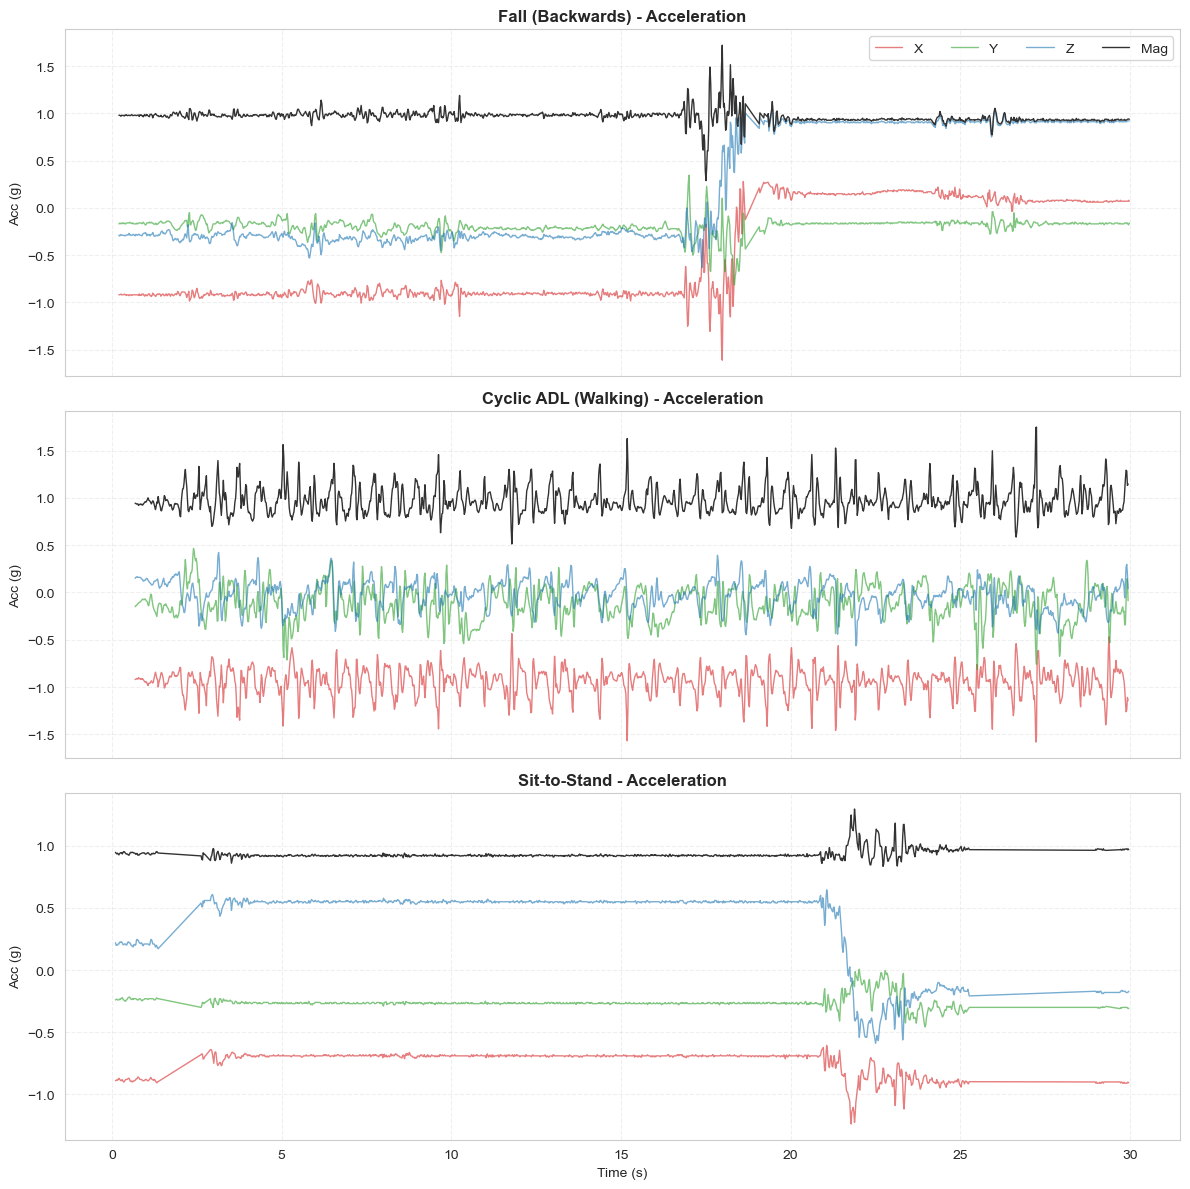

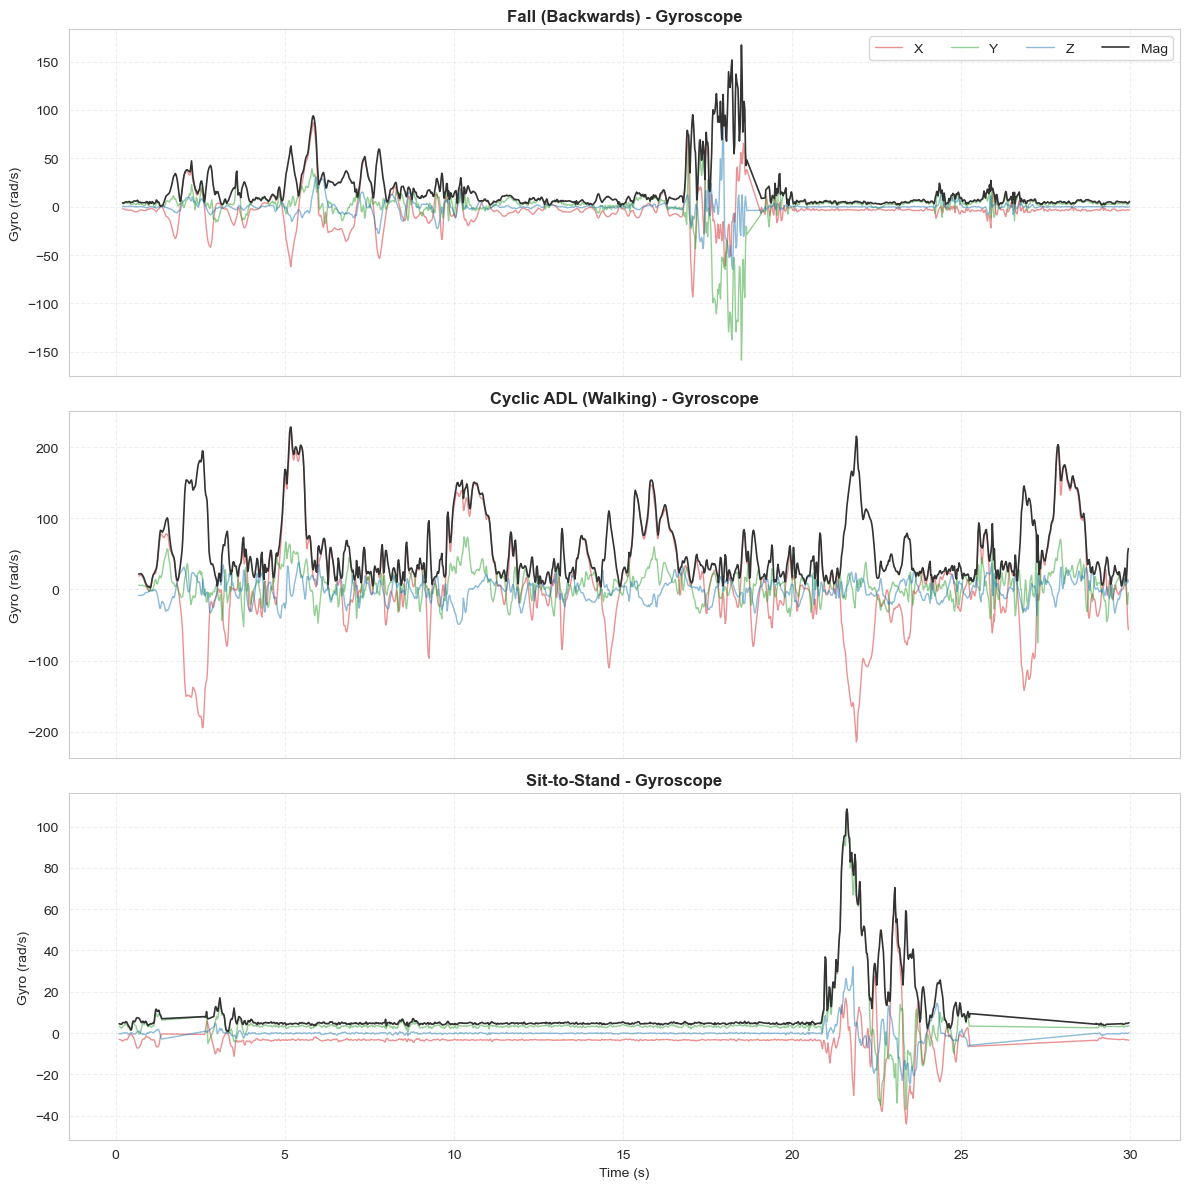


=== Figure 2: Data Distribution (Histograms) ===


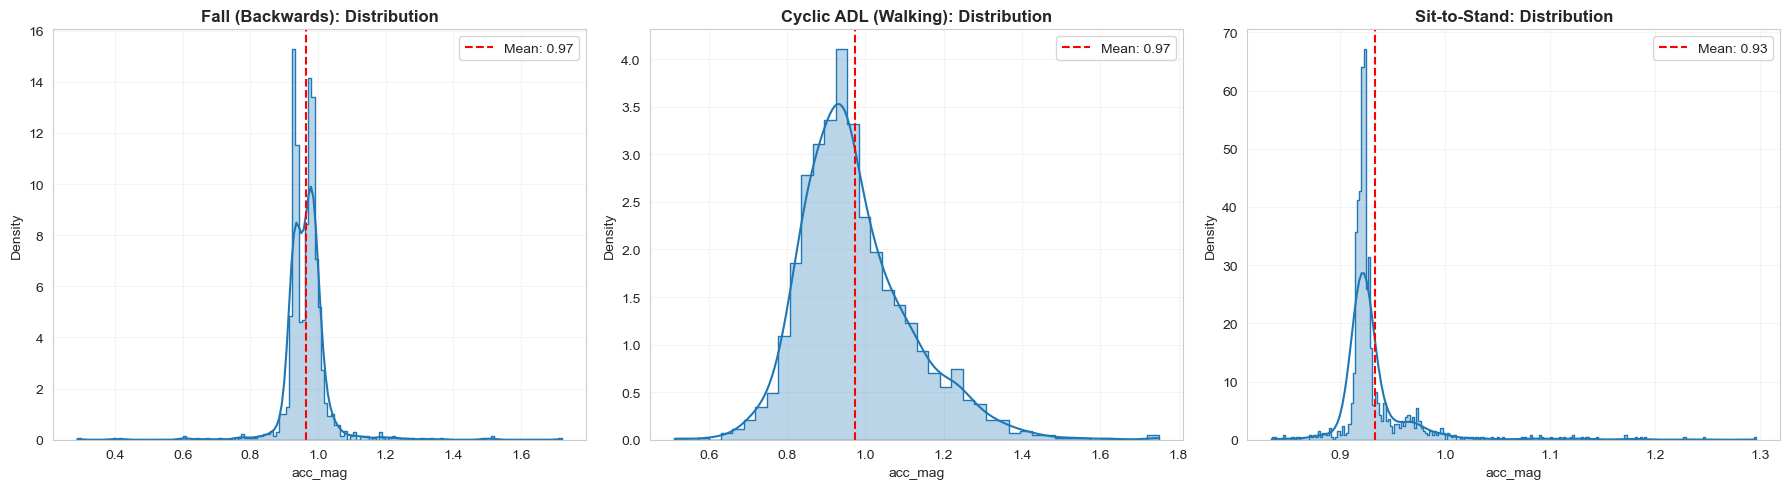


=== Figure 3: Feature Relationships (Scatter Plots) ===


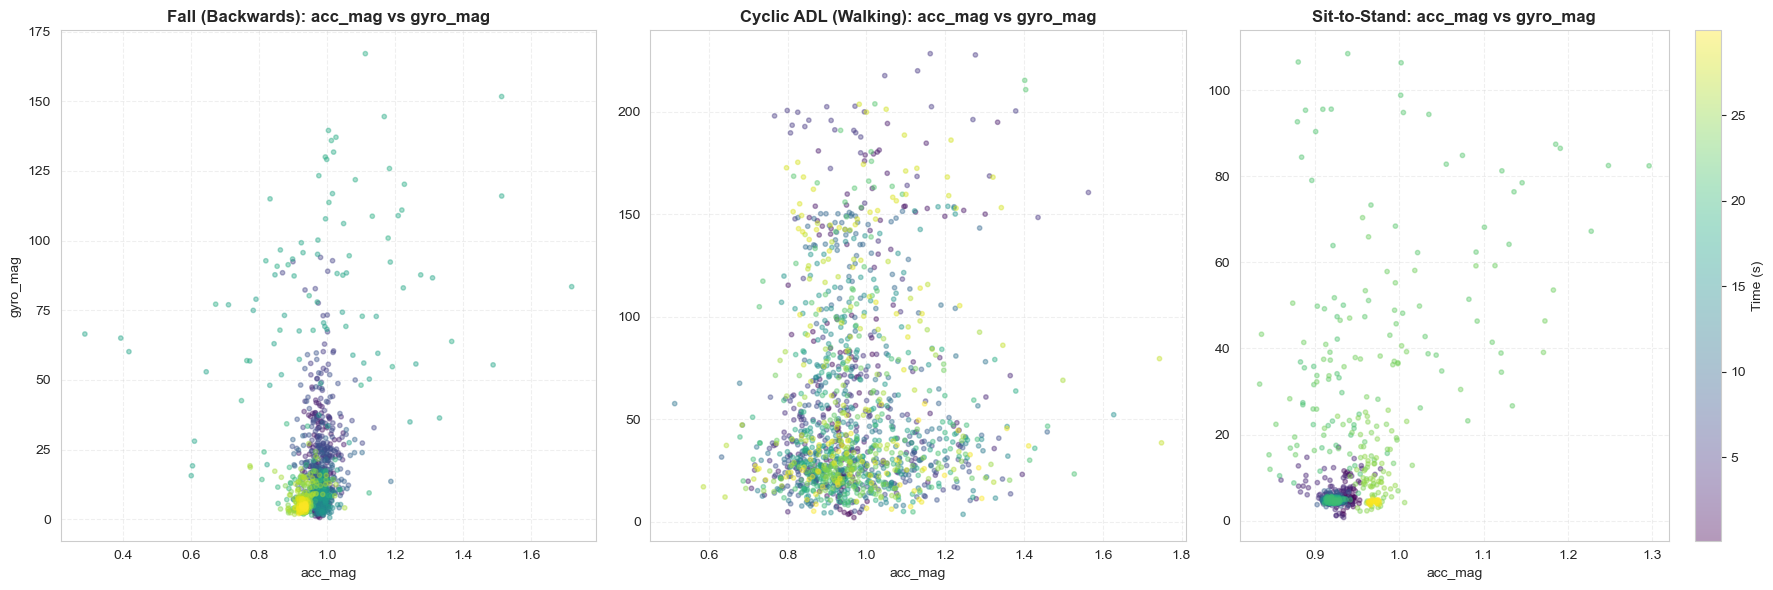

In [12]:
# raw data visualization

targets = {
    "Fall (Backwards)": "Fallingbackwards_p4_1",  
    "Cyclic ADL (Walking)": "Walking_p4_2_35sek",      
    "Sit-to-Stand": "SittingToStanding"     
}


all_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, "long", "*.parquet")))
data_dict = {}


print("Loading representative files...")
for label, keyword in targets.items():
    matches = [f for f in all_files if keyword.lower() in os.path.basename(f).lower()]
    if matches:
        data_dict[label] = data_loader.load_long_parquet(matches[0])
        print(f"Loaded {label}")
    else:
        print(f" Warning: File not found for keyword '{keyword}'")


if len(data_dict) > 0:
    print("\n=== Figure 1: Time Series Trends (Line Plots) ===")
    viz.plot_raw_lines(data_dict, feature="acc_mag")
    
    print("\n=== Figure 2: Data Distribution (Histograms) ===")
    viz.plot_raw_hists(data_dict, feature="acc_mag")
    
    print("\n=== Figure 3: Feature Relationships (Scatter Plots) ===")
    viz.plot_raw_scatter(data_dict, x_col="acc_mag", y_col="gyro_mag")
else:
    print("Oh no..... No data loaded.")
  


# TSA

- loading data
- handling gaps and interpolation


Loaded 167 files.
Applying Butterworth Low-Pass (Cutoff=15Hz) respecting seg_id...
Smoothing & Recalculation complete.


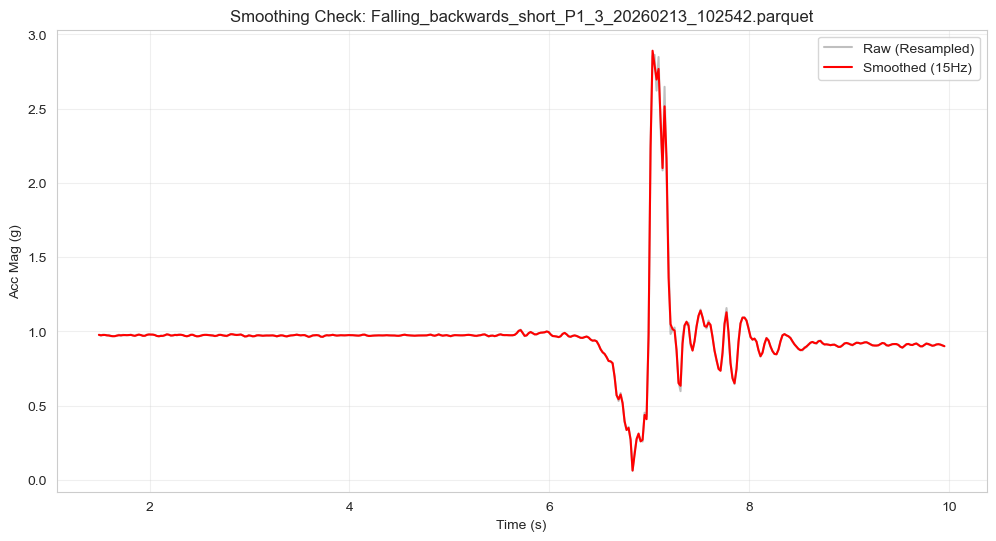

In [13]:
# smoothing
PROCESSED_DIR = "Processed_data/long" 
files = glob.glob(os.path.join(PROCESSED_DIR, "*.parquet"))


data_dict = {}
for f in files:
    data_dict[os.path.basename(f)] = pd.read_parquet(f)

print(f"Loaded {len(data_dict)} files.")

# smoothing
smoothed_data = feats.apply_lowpass_filter(data_dict, cutoff=15, fs=50)

# Raw vs Smoothed
fall_files = [k for k in data_dict.keys() if "fall" in k.lower()]
if fall_files:
    sample_key = fall_files[0]
    
    raw_df = data_dict[sample_key]
    smooth_df = smoothed_dict[sample_key]
    
    plt.figure(figsize=(12, 6))
    plt.plot(raw_df['t_s'], raw_df['acc_mag'], color='gray', alpha=0.5, label='Raw (Resampled)')
    plt.plot(smooth_df['t_s'], smooth_df['acc_mag'], color='red', linewidth=1.5, label='Smoothed (15Hz)')
    
    plt.title(f"Smoothing Check: {sample_key}")
    plt.xlabel("Time (s)")
    plt.ylabel("Acc Mag (g)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No fall files found to visualize.")

# Feature extraction
- Time-domain features: Mean, variance, standard deviation, skewness.
- Frequency-domain features: Spectral entropy, energy.

In [15]:

print("\nStarting feature extraction on smoothed data...")
smooth_feature_df = feats.build_feature_dataset(smoothed_data, window_s=2.0, step_s=1.0, fs=50)

print(f"Extraction complete. Generated {len(smooth_feature_df)} windows.")
smooth_feature_df.head()
print("Class distribution:")
print(smooth_feature_df["activity"].value_counts())


Starting feature extraction on smoothed data...
Extraction complete. Generated 3231 windows.
Class distribution:
activity
Fall         1182
Other         757
Walking       656
Sit-Stand     636
Name: count, dtype: int64


In [16]:
import pandas as pd
import analysis_features as feats # 确保加载了你的模块

# 1. 加载最终生成的特征集
df = pd.read_csv(os.path.join(PROCESSED_DIR, "final_feature_dataset.csv"))

# 2. 筛选出所有 Fall 文件
fall_df = df[df['activity'] == 'Fall']

if fall_df.empty:
    print("警报：特征集中没有任何 Fall 样本！可能是所有跌倒都被切窗逻辑丢弃了！")
else:
    # 3. 检查每个 Fall 文件的最大加速度
    # 如果数据完整，每个 Fall 文件至少应该贡献一个 > 1.6g 的窗口
    file_stats = fall_df.groupby('file')['acc_max'].max().reset_index()
    
    print("=== Fall Files Survival Check ===")
    print(f"Total Fall Files in Dataset: {len(file_stats)}")
    
    # 看看哪些文件的最大值还是很小 (说明真正的冲击被丢了)
    weak_falls = file_stats[file_stats['acc_max'] < 1.5]
    
    if not weak_falls.empty:
        print(f"\n[Warning] {len(weak_falls)} files have NO impact window (>1.5g).")
        print("They likely suffered from DATA LOSS (Gaps) during the fall.")
        print(weak_falls)
    else:
        print("\n[Success] All fall files have at least one high-impact window.")
        print("Latency did not cause data loss.")

FileNotFoundError: [Errno 2] No such file or directory: 'Processed_data/long/final_feature_dataset.csv'

In [ ]:
# smoothing
smoothed_data = feats.apply_lowpass_filter(data_dict, cutoff=15, fs=50)

# Raw vs Smoothed
fall_files = [k for k in data_dict.keys() if "fall" in k.lower()]
if fall_files:
    sample_key = fall_files[0]
    
    raw_df = data_dict[sample_key]
    smooth_df = smoothed_data[sample_key]  # Changed from smoothed_dict to smoothed_data
    
    plt.figure(figsize=(12, 6))
    plt.plot(raw_df['t_s'], raw_df['acc_mag'], color='gray', alpha=0.5, label='Raw (Resampled)')
    plt.plot(smooth_df['t_s'], smooth_df['acc_mag'], color='red', linewidth=1.5, label='Smoothed (15Hz)')
    
    plt.title(f"Smoothing Check: {sample_key}")
    plt.xlabel("Time (s)")
    plt.ylabel("Acc Mag (g)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No fall files found to visualize.")

In [6]:

# Run Feature Extraction Pipeline
print("Starting feature extraction on SMOOTHED data..")
# ?? Window size = 2.0s is chosen to capture a fall event 
# ?? Step size = 1.0s
feature_df = feats.build_feature_dataset(smoothed_cache, window_s=2.0, step_s=0.5, fs=50)

print(f"Extraction complete. Generated {len(feature_df)} windows.")
print("Class distribution:")
print(feature_df["activity"].value_counts())

feature_df.head()

Starting feature extraction on SMOOTHED data..
Extraction complete. Generated 6371 windows.
Class distribution:
activity
Sit-Stand    2760
Fall         2344
Walking      1267
Name: count, dtype: int64


,acc_max,acc_mean,acc_var,acc_std,gyro_max,gyro_mean,gyro_var,gyro_std,acc_skew,acc_kurtosis,acc_spec_energy,acc_spec_entropy,gyro_spec_energy,gyro_spec_entropy,file,label,activity,t_start,t_end
0,1.015094,0.983445,0.000249,0.015791,23.447628,11.257134,20.547256,4.532908,0.267800,-1.022505,3255.728043,0.624052,613514.393749,1.199688,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,0.591289,2.564783
1,1.009694,0.977252,0.000119,0.010926,23.447628,10.469372,24.095182,4.908684,0.450741,0.523079,3230.935355,0.626597,329140.976102,0.940115,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.091226,3.064821
2,0.989677,0.976393,0.000057,0.007527,12.734876,7.145860,9.112024,3.018613,-0.464591,-0.599930,3244.855754,0.628070,212895.165774,0.965253,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.589988,3.564779
3,1.076899,0.977650,0.000427,0.020662,20.977029,7.129075,11.883202,3.447202,-0.457242,14.451630,3261.667524,0.628750,119595.186646,0.940336,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.089738,4.064776
4,1.076899,0.977818,0.000463,0.021520,20.977029,7.076736,13.484580,3.672136,-0.465161,11.971901,3261.792606,0.634943,156151.741912,1.392322,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.591526,4.564791


/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


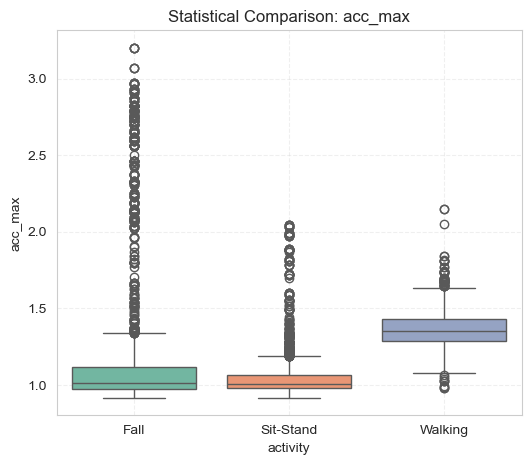

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


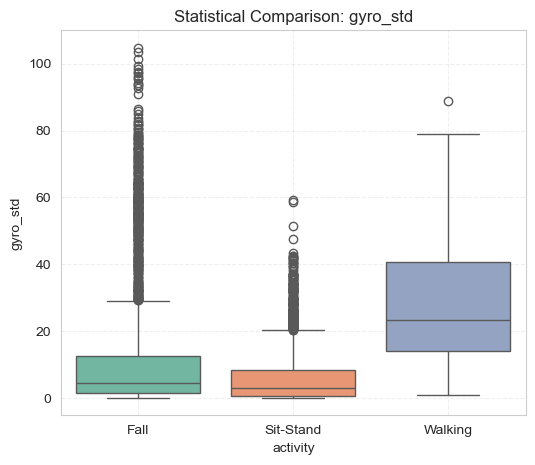

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


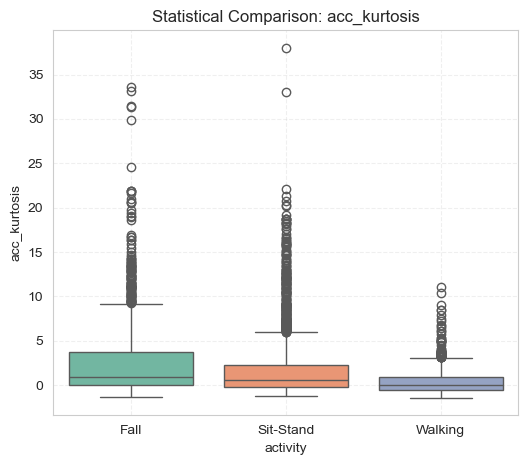

In [7]:

# check max acceleration
viz.plot_boxplot_stat(feature_df, feature="acc_max", label_col="activity")

#check Gyroscope Std
viz.plot_boxplot_stat(feature_df, feature="gyro_std", label_col="activity")

# check Kurtosis
viz.plot_boxplot_stat(feature_df, feature="acc_kurtosis", label_col="activity")


The distribution of acc_max for the 'Fall' class shows a low median but significant positive outliers. This indicates that while the majority of the fall recording consists of low-intensity periods (lying down), the specific impact events are captured as extreme values, distinct from ADLs.


Surprisingly, 'Walking' exhibits a higher median gyro_std than 'Fall'. This is because walking is a continuous dynamic activity with constant rotation, whereas a fall is a transient event often followed by a long static period. The high variability in the 'Fall' class (scattered points) reflects its unpredictable nature.

`acc_kurtosis` proves to be a robust discriminator. The 'Fall' class exhibits the highest extreme values. This confirms that falls are characterized by impulsive spikes in acceleration, distinct from the repetitive patterns of walking or the smoother transitions of sitting down."

The challenge of Fall Detection lies in distinguishing a brief, high-intensity impact (Outliers) from continuous daily activities (Walking). Features like `acc_kurtosis` and `acc_max` (specifically their extreme values) are key to identifying these transient events.

## 3D projection

Binary Class Distribution:
binary_class
Non-Fall    4027
Fall        2344
Name: count, dtype: int64

Plotting 3D Feature Space (Fall vs Non-Fall)...


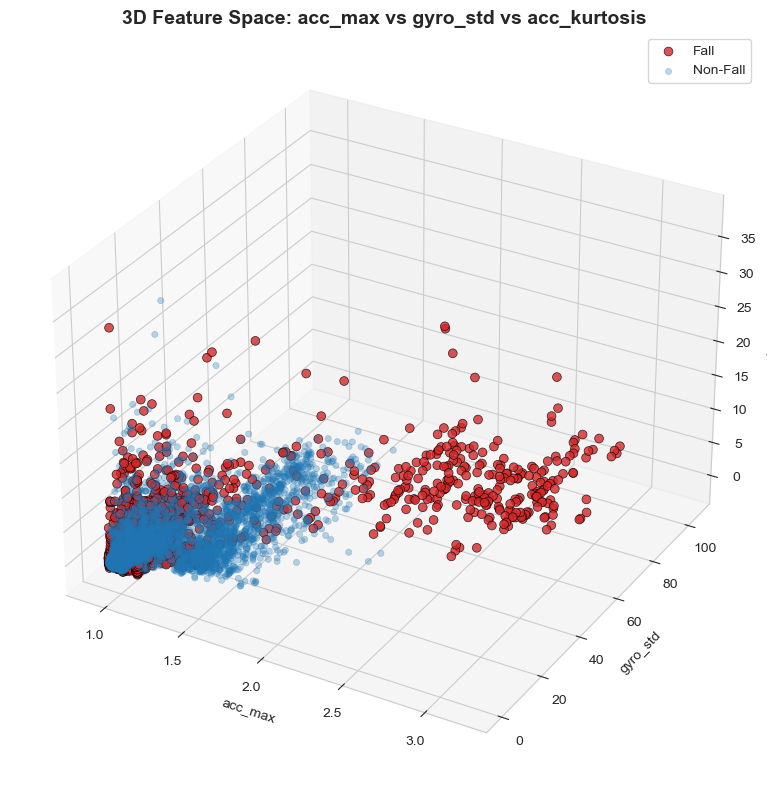

In [8]:
# %matplotlib widget
# binary labels, fall vs non-fall
# new dataframe to avoid modifying the original one
binary_df = feature_df.copy()

# If it's 'Fall', keep it. Everything else becomes 'Non-Fall'.
binary_df["binary_class"] = binary_df["activity"].apply(
    lambda x: "Fall" if x == "Fall" else "Non-Fall"
)

# distribution to check balance
print("Binary Class Distribution:")
print(binary_df["binary_class"].value_counts())

# Visualize in 3D
# Selected features based on previous boxplot analysis:
# - acc_max: Represents Impact Intensity
# - gyro_std: Represents Rotational Violence
# - acc_kurtosis: Represents Signal Impulsiveness (Spikiness)

print("\nPlotting 3D Feature Space (Fall vs Non-Fall)...")
viz.plot_3d_feature_space(
    binary_df, 
    x="acc_max", 
    y="gyro_std", 
    z="acc_kurtosis", 
    label_col="binary_class"
)

In [9]:
if "binary_df" not in locals():
    binary_df = feature_df.copy()
    binary_df["binary_class"] = binary_df["activity"].apply(lambda x: "Fall" if x == "Fall" else "Non-Fall")




all_features = [
    # Acceleration (acc_mag)
    "acc_max",
    "acc_mean",
    "acc_var",
    "acc_std",
    "acc_skew",
    "acc_kurtosis",
    "acc_spec_energy",
    "acc_spec_entropy",

    # Gyroscope (gyro_mag)
    "gyro_max",
    "gyro_mean",
    "gyro_var",
    "gyro_std",
    "gyro_spec_energy",
    "gyro_spec_entropy",
]

# result
stats_report = feats.get_statistical_report(
    binary_df, 
    all_features, 
    group_col="binary_class", 
    target_label="Fall"
)


display(stats_report)

,Feature,Fall (Mean +/- Std),Non-Fall (Mean +/- Std),t-statistic,p-value,Significance
0,acc_max,1.21 +/- 0.49,1.15 +/- 0.21,5.33,1.07e-07,***
1,acc_mean,0.97 +/- 0.04,0.98 +/- 0.03,-12.75,1.83e-36,***
2,acc_var,0.02 +/- 0.05,0.01 +/- 0.01,10.32,1.73e-24,***
3,acc_std,0.07 +/- 0.12,0.06 +/- 0.06,3.15,1.62e-03,**
4,acc_skew,0.33 +/- 1.14,0.35 +/- 0.82,-0.44,6.58e-01,ns
5,acc_kurtosis,2.36 +/- 3.69,1.32 +/- 2.96,11.62,1.01e-30,***
6,acc_spec_energy,3254.24 +/- 394.95,3313.85 +/- 220.55,-6.72,2.10e-11,***
7,acc_spec_entropy,0.69 +/- 0.19,0.67 +/- 0.07,4.61,4.25e-06,***
8,gyro_max,57.31 +/- 80.18,57.15 +/- 57.77,0.09,9.30e-01,ns
9,gyro_mean,17.85 +/- 19.99,24.53 +/- 24.90,-11.73,2.15e-31,***


In [10]:
import analysis_features as feats

filtered_df = binary_df.copy()

std_threshold = 0.05 

silent_fall_indices = filtered_df[
    (filtered_df["binary_class"] == "Fall") & 
    (filtered_df["acc_std"] < std_threshold) 
].index


active_stats_df = filtered_df.drop(silent_fall_indices)


print(f"Original Windows: {len(binary_df)}")
print(f"Active Windows: {len(active_stats_df)}")
print(f"Dropped {len(silent_fall_indices)} 'silent' windows.")


refined_report = feats.get_statistical_report(
    active_stats_df, 
    all_features, 
    group_col="binary_class", 
    target_label="Fall"
)

display(refined_report)

Original Windows: 6371
Active Windows: 4615
Dropped 1756 'silent' windows.


,Feature,Fall (Mean +/- Std),Non-Fall (Mean +/- Std),t-statistic,p-value,Significance
0,acc_max,1.82 +/- 0.66,1.15 +/- 0.21,24.17,8.29e-91,***
1,acc_mean,0.99 +/- 0.05,0.98 +/- 0.03,2.61,9.33e-03,**
2,acc_var,0.07 +/- 0.08,0.01 +/- 0.01,19.79,2.98e-67,***
3,acc_std,0.22 +/- 0.15,0.06 +/- 0.06,25.98,3.70e-101,***
4,acc_skew,1.11 +/- 1.49,0.35 +/- 0.82,12.08,1.99e-30,***
5,acc_kurtosis,4.55 +/- 4.34,1.32 +/- 2.96,17.46,1.51e-56,***
6,acc_spec_energy,3487.77 +/- 596.20,3313.85 +/- 220.55,7.00,6.60e-12,***
7,acc_spec_entropy,0.86 +/- 0.33,0.67 +/- 0.07,14.24,8.50e-40,***
8,gyro_max,160.28 +/- 98.87,57.15 +/- 57.77,24.69,2.60e-95,***
9,gyro_mean,43.98 +/- 23.10,24.53 +/- 24.90,18.87,5.36e-66,***


## features selection
acc_std
acc_max
acc_spec_entropy

gyro_std
gyro_max
gyro_mean
gyro_spec_entropy

After applying an activity-based window filtering step, several features that were previously significant lost their discriminative power. This indicates that their apparent significance was largely driven by differences between static and active windows rather than fall-specific dynamics. In contrast, variability- and structure-based features, particularly acceleration standard deviation and spectral entropy, became more discriminative under active movement conditions, highlighting their relevance for fall detection.

# Event Segmentation
Isolate specific events from your time series, such as potential falls. Suggested methods:
- Threshold-based segmentation.
- More advanced techniques if appropriate for your data.

Detected 2 events:
  Event 1: 20.14s -> 20.92s (Duration: 0.78s)
  Event 2: 38.10s -> 39.68s (Duration: 1.57s)


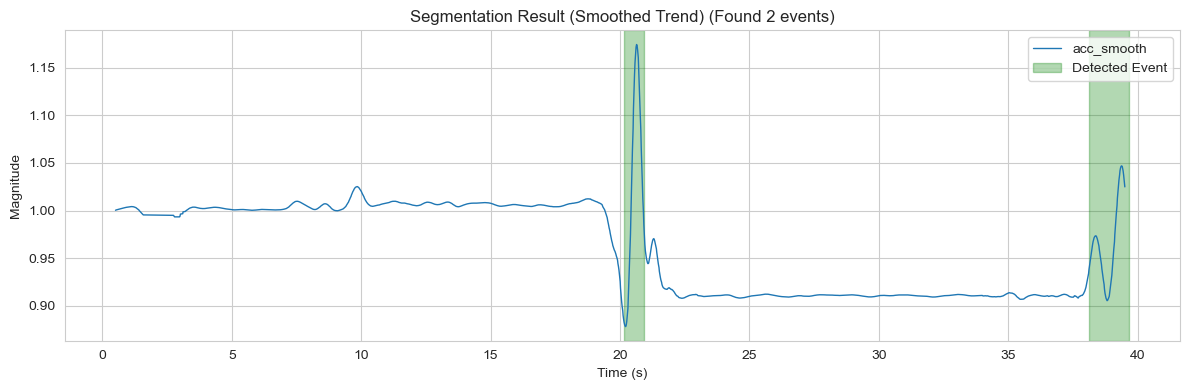

In [11]:

# parameters for event detection
# threshold = 0.2 

detected_events = feats.detect_events(
    df_test, 
    signal_col="acc_mag", 
    fs=50, 
    window_s=0.5,   
    threshold=0.2,  
    merge_gap_s=1.5 # gap less than 1.5s is considered the same event
)

# add smoothing data
df_test["acc_smooth"] = df_test["acc_mag"].rolling(
    window=50, 
    win_type='gaussian', 
    center=True
).mean(std=10)

print(f"Detected {len(detected_events)} events:")
for i, (s, e) in enumerate(detected_events):
    print(f"  Event {i+1}: {s:.2f}s -> {e:.2f}s (Duration: {e-s:.2f}s)")


viz.plot_segmentation(
    df_test, 
    detected_events, 
    title=f"Segmentation Result (Smoothed Trend)", 
    signal_col="acc_smooth" )

`rolling_std`
$$\sigma = \sqrt{\frac{1}{N}\sum (x_i - \bar{x})^2}$$
std<0.2--> noise

std>0.2--> event

`merging_gap_s`
the gap (signal interruption due to strenuous exercise) <1.5s, take them as a same event but different stages

----------
Feature Computation: We calculated the Rolling Standard Deviation (Window=0.5s) of the acceleration magnitude. This metric serves as a proxy for "kinetic energy" or "activity intensity," which is more robust to sensor orientation than raw amplitude.

Thresholding: A threshold of 0.2 was applied. Periods exceeding this value were marked as "Active Regions."

Post-processing (Merging): To prevent fragmentation of single events (e.g., a fall followed by a bounce), adjacent active regions separated by less than 1.5s were merged into a single continuous event.



**problem**
how to select threshold?

# preprocessing

**IQR interquartile range** --> outlier detection

IQR = Q3(75th percentile of x)- Q1(25th percentile of x)

- lower bound = Q1-k*IQR
- upper bound = Q3+k*IQR
k =1.5 --> tukey rule;
we have k =3, so it is more conservative



**Z-score** ---> standardization
$z_i = \frac{x_i - \mu}{\theta}$
- $\mu$ mean of this feature
- $\theta$ std

In [12]:
import preprocessing as pre



if 'binary_df' not in locals():
    print("Ohno..... No feature dataset available for preprocessing.")
else:
   
    clean_df = pre.clean_feature_matrix(binary_df)
    

    feature_columns = [
    "acc_max",
    "acc_std",
    "acc_spec_entropy",
    "gyro_max",
    "gyro_mean",
    "gyro_std",
    "gyro_spec_entropy",]
    

    valid_features = [c for c in feature_columns if c in clean_df.columns]
    
    # remove outliers using IQR method with a factor of 3.0 (more aggressive)
    # clean_df = pre.remove_outliers(clean_df, valid_features, factor=3.0)
    
    # Normalization z-score
    # final_dataset, scaler = pre.normalize_features(clean_df, valid_features, method='z-score')
    final_dataset = clean_df.copy()

    # print("\nOriginal Means (acc_max):", binary_df["acc_max"].mean())
    # print("Scaled Means (acc_max):  ", round(final_dataset["acc_max"].mean(), 2))
    
    display(final_dataset.head())
    
    final_dataset.to_csv(os.path.join(PROCESSED_DIR, "WinSize5Gau_Win2s_05s_week4.csv"), index=False)
    print(f"Dataset saved to {os.path.join(PROCESSED_DIR, 'WinSize5Gau_Win2s_05s_week4.csv')}")

[Preprocessing] Outliers removed: 1057 rows (Factor=3.0).
[Preprocessing] Features normalized using z-score.

Original Means (acc_max): 1.1718949920906854
Scaled Means (acc_max):   -0.0


,acc_max,acc_mean,acc_var,acc_std,gyro_max,gyro_mean,gyro_var,gyro_std,acc_skew,acc_kurtosis,acc_spec_energy,acc_spec_entropy,gyro_spec_energy,gyro_spec_entropy,file,label,activity,t_start,t_end,binary_class
0,-0.361839,0.983445,0.000249,-0.364684,-0.312635,-0.214803,20.547256,-0.334058,0.267800,-1.022505,3255.728043,-0.583373,613514.393749,0.515064,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,0.591289,2.564783,Fall
1,-0.398736,0.977252,0.000119,-0.477600,-0.312635,-0.275127,24.095182,-0.290106,0.450741,0.523079,3230.935355,-0.503389,329140.976102,-0.252124,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.091226,3.064821,Fall
2,-0.535521,0.976393,0.000057,-0.556477,-0.618889,-0.529628,9.112024,-0.511175,-0.464591,-0.599930,3244.855754,-0.457090,212895.165774,-0.177826,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,1.589988,3.564779,Fall
3,0.060496,0.977650,0.000427,-0.251617,-0.383264,-0.530913,11.883202,-0.461046,-0.457242,14.451630,3261.667524,-0.435723,119595.186646,-0.251470,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.089738,4.064776,Fall
4,0.060496,0.977818,0.000463,-0.231695,-0.383264,-0.534921,13.484580,-0.434737,-0.465161,11.971901,3261.792606,-0.241104,156151.741912,1.084408,FallingForwards_p1_1_35sek_20260206_113359.par...,1,Fall,2.591526,4.564791,Fall


Dataset saved to Processed_data/WinSize5Gau_Win2s_05s_week4.csv
